In [18]:
# 데이터 처리 및 분석
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
from statsmodels.stats.contingency_tables import Table  # 카이제곱 사후분석용 (조정 잔차)
from itertools import combinations  # 쌍별 효과크기 계산용
import pingouin as pg
import scikit_posthocs as sp

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [19]:
# 데이터 로드
df = pd.read_csv('./data/merged_data.csv')
print("\n데이터 로드 완료!")
print(f"데이터셋 크기: {df.shape}")


데이터 로드 완료!
데이터셋 크기: (96432, 22)


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 96432 entries, 0 to 96431
Data columns (total 22 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       96432 non-null  str    
 1   customer_id                    96432 non-null  str    
 2   order_purchase_timestamp       96432 non-null  str    
 3   order_approved_at              96432 non-null  str    
 4   order_delivered_carrier_date   96432 non-null  str    
 5   order_delivered_customer_date  96432 non-null  str    
 6   order_estimated_delivery_date  96432 non-null  str    
 7   customer_unique_id             96432 non-null  str    
 8   customer_city                  96432 non-null  str    
 9   customer_state                 96432 non-null  str    
 10  total_items_count              96432 non-null  int64  
 11  product_id                     96432 non-null  str    
 12  seller_id                      96432 non-null  str    
 1

In [21]:
df = df.dropna(subset=['review_score'])

In [22]:
df['review_comment_title'] = df['review_comment_title'].fillna('')
df['review_comment_message'] = df['review_comment_message'].fillna('')

In [23]:
print(df.isnull().sum())

order_id                            0
customer_id                         0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date        0
order_delivered_customer_date       0
order_estimated_delivery_date       0
customer_unique_id                  0
customer_city                       0
customer_state                      0
total_items_count                   0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
review_score                        0
review_comment_title                0
review_comment_message              0
product_category_name_english    1370
seller_city                         0
seller_state                        0
dtype: int64


In [24]:
# 데이터 타입 변환
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])
df['order_delivered_carrier_date'] = pd.to_datetime(df['order_delivered_carrier_date'])

In [25]:
# 파생 변수 생성
# 배송 관련 파생 변수 생성 (orders 테이블 기준)
df['purchase_to_delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['is_late'] = df['order_delivered_customer_date'] > df['order_estimated_delivery_date']

# 주문 시점의 요일 정보 추가
df['order_purchase_dayofweek'] = df['order_purchase_timestamp'].dt.dayofweek
df['order_purchase_dayofweek'] = df['order_purchase_dayofweek'].map({
0: 'monday',
1: 'tuesday',
2: 'wednesday',
3: 'thursday',
4: 'friday',
5: 'saturday',
6: 'sunday'
})
df['order_purchase_dayofweek'] = df['order_purchase_dayofweek'].astype('category')

# 주문 시점의 월 정보 추가
df['order_purchase_month'] = df['order_purchase_timestamp'].dt.month
df['order_purchase_month'] = df['order_purchase_month'].astype('category')
df['order_purchase_month'] = df['order_purchase_month'].cat.set_categories([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12], ordered=True)
df['order_purchase_month'] = df['order_purchase_month'].cat.codes
df['order_purchase_month'] = df['order_purchase_month'].astype(int)
df['order_purchase_month'] = df['order_purchase_month'].map({
0: 1,
1: 2,
2: 3,
3: 4,
4: 5,
5: 6,
6: 7,
7: 8,
8: 9,
9: 10,
10: 11,
11: 12
})
df['order_purchase_month'] = df['order_purchase_month'].astype(int)

# 주문 시점의 연도 정보 추가
df['order_purchase_year'] = df['order_purchase_timestamp'].dt.year
df['order_purchase_year'] = df['order_purchase_year'].astype(int)

### 실제 배송 소요 일수 계산 (order_delivered_customer_date - order_purchase_timestamp)
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

### 출고 소요 일수 계산 (order_delivered_carrier_date - order_purchase_timestamp)
df['dispatch_days'] = (df['order_delivered_carrier_date'] - df['order_purchase_timestamp']).dt.days

### 예상 배송 소요 일수 계산 (order_estimated_delivery_date - order_purchase_timestamp)
df['expected_delivery_days'] = (df['order_estimated_delivery_date'] - df['order_purchase_timestamp']).dt.days

### 배송 지연 일수 계산 (order_estimated_delivery_date - order_delivered_customer_date)
df['delivery_error_days'] = (df['order_estimated_delivery_date'] - df['order_delivered_customer_date']).dt.days


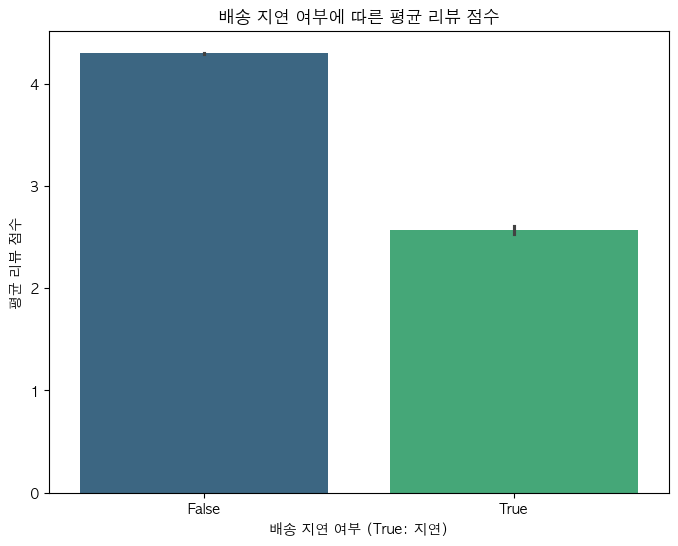

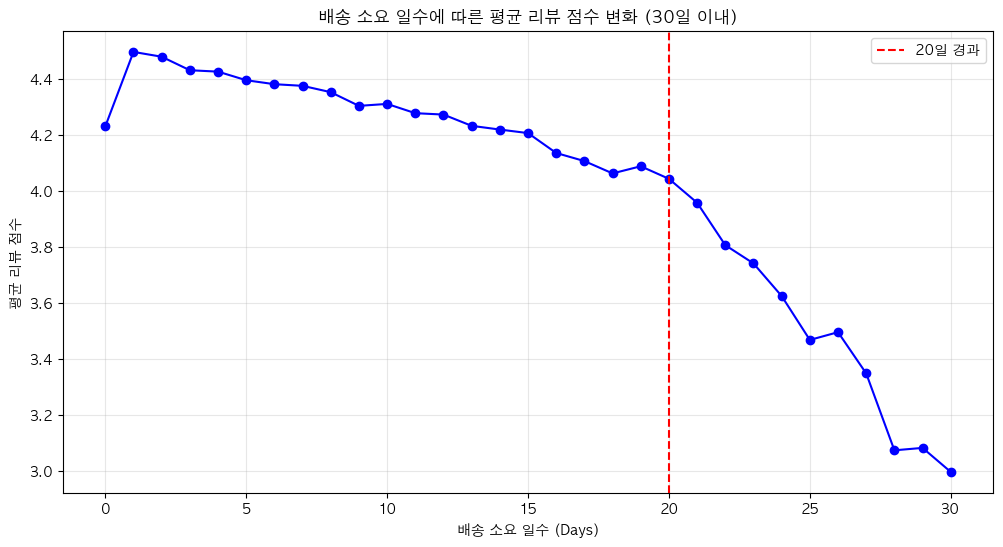

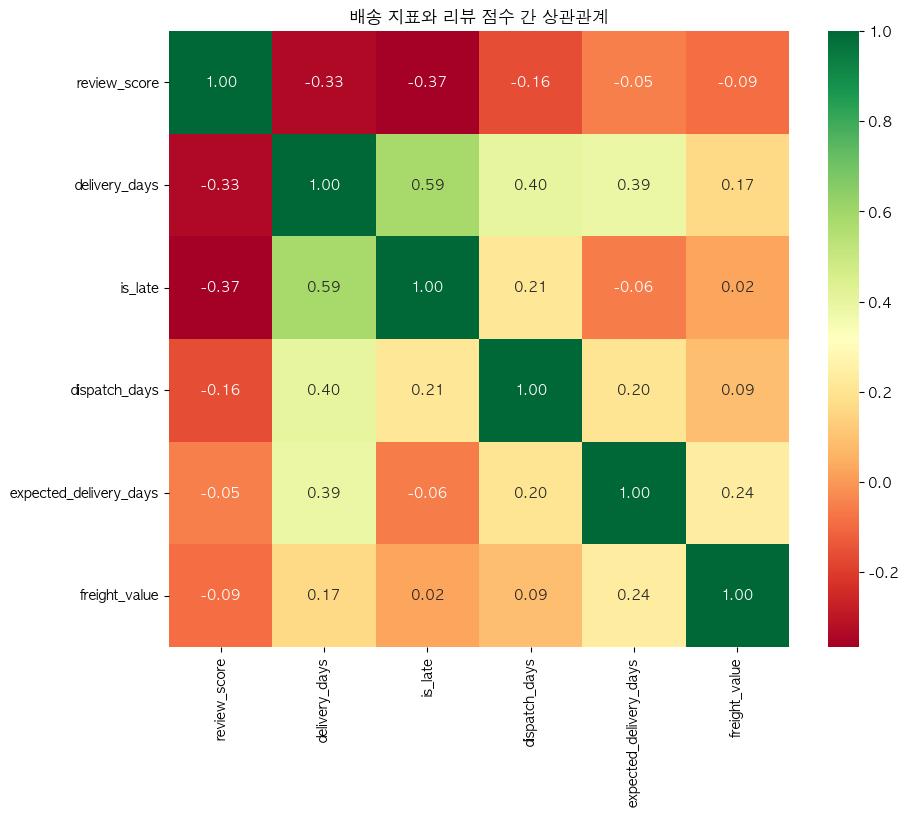

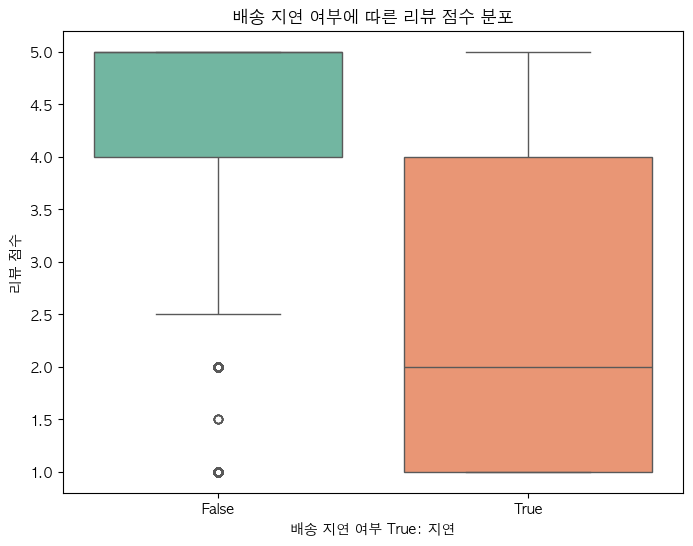

In [26]:
# 1. 배송 지연 여부에 따른 평균 리뷰 점수
plt.figure(figsize=(8, 6))
sns.barplot(x='is_late', y='review_score', data=df, palette='viridis')
plt.title('배송 지연 여부에 따른 평균 리뷰 점수')
plt.xlabel('배송 지연 여부 (True: 지연)')
plt.ylabel('평균 리뷰 점수')
plt.show()

# 2. 배송 소요 일수와 리뷰 점수의 관계 (Line Plot)
# 배송 일수가 너무 긴 극단치(Outlier)를 제외하고 30일 이내 데이터만 보기
plt.figure(figsize=(12, 6))
delivery_trend = df[df['delivery_days'] <= 30].groupby('delivery_days')['review_score'].mean()
plt.plot(delivery_trend.index, delivery_trend.values, marker='o', linestyle='-', color='b')
plt.axvline(x=20, color='r', linestyle='--', label='20일 경과') # 20일 기준선
plt.title('배송 소요 일수에 따른 평균 리뷰 점수 변화 (30일 이내)')
plt.xlabel('배송 소요 일수 (Days)')
plt.ylabel('평균 리뷰 점수')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 3. 주요 배송 지표 간의 상관관계 히트맵 (Heatmap)
plt.figure(figsize=(10, 8))
cols_to_corr = ['review_score', 'delivery_days', 'is_late', 'dispatch_days', 'expected_delivery_days', 'freight_value']
sns.heatmap(df[cols_to_corr].corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('배송 지표와 리뷰 점수 간 상관관계')
plt.show()

# 4. 배송 지연 여부에 따른 리뷰 점수 분포 (Box Plot)
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_late', y='review_score', data=df, palette='Set2')
plt.title('배송 지연 여부에 따른 리뷰 점수 분포')
plt.xlabel('배송 지연 여부 True: 지연')
plt.ylabel('리뷰 점수')
plt.show()

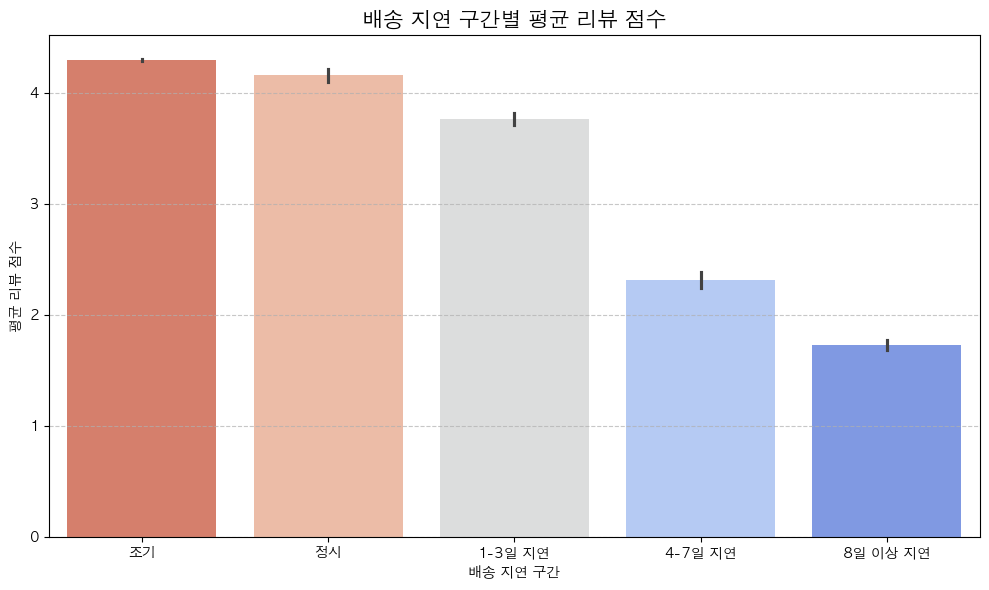

In [27]:
# 1. 배송 지연 구간별 평점 하락폭 분석 (Heatmap/Bar)
# delivery_error_days: 양수면 조기 도착, 음수면 지연 도착
def bin_delay(x):
    if x > 0: return '조기'
    elif x == 0: return '정시'
    elif x >= -3: return '1-3일 지연'
    elif x >= -7: return '4-7일 지연'
    else: return '8일 이상 지연'

df['delay_range'] = df['delivery_error_days'].apply(bin_delay)
order = ['조기', '정시', '1-3일 지연', '4-7일 지연', '8일 이상 지연']

plt.figure(figsize=(10, 6))
sns.barplot(x='delay_range', y='review_score', data=df, order=order, palette='coolwarm_r')
plt.title('배송 지연 구간별 평균 리뷰 점수', fontsize=15)
plt.xlabel('배송 지연 구간')
plt.ylabel('평균 리뷰 점수')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

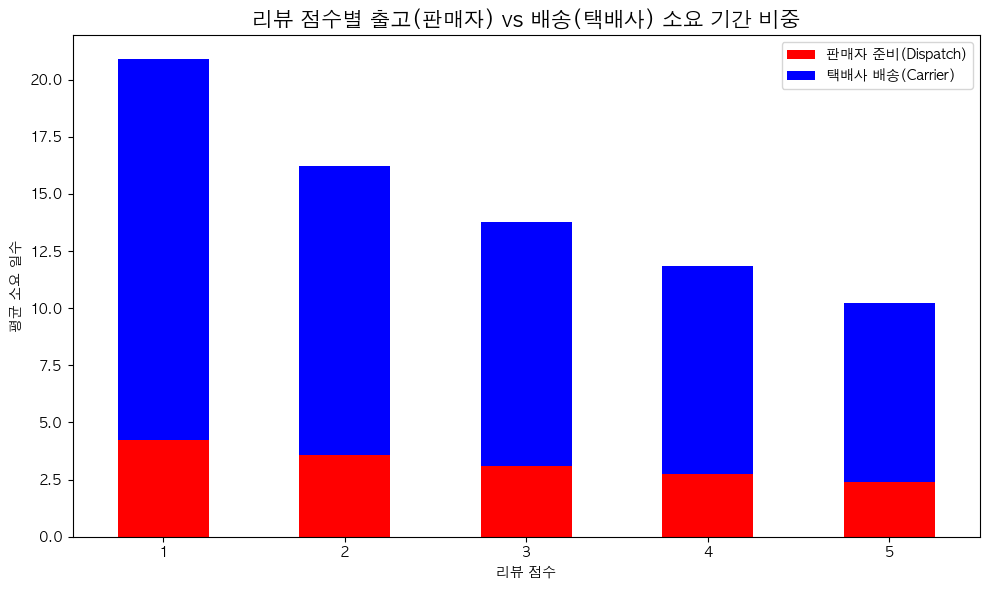

In [28]:
# 2. 판매자 vs 택배사 책임 소재 분석
# 전체 배송일(delivery_days) = 출고 소요(dispatch_days) + 순수 배송(carrier_days)
df['carrier_days'] = df['delivery_days'] - df['dispatch_days']

# 평점별 평균 소요 시간 비교
responsibility = df.groupby(df['review_score'].round().astype(int))[['dispatch_days', 'carrier_days']].mean()
responsibility.plot(kind='bar', stacked=True, figsize=(10, 6), color=['red', 'blue'])
plt.title('리뷰 점수별 출고(판매자) vs 배송(택배사) 소요 기간 비중', fontsize=15)
plt.xlabel('리뷰 점수')
plt.ylabel('평균 소요 일수')
plt.legend(['판매자 준비(Dispatch)', '택배사 배송(Carrier)'])
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

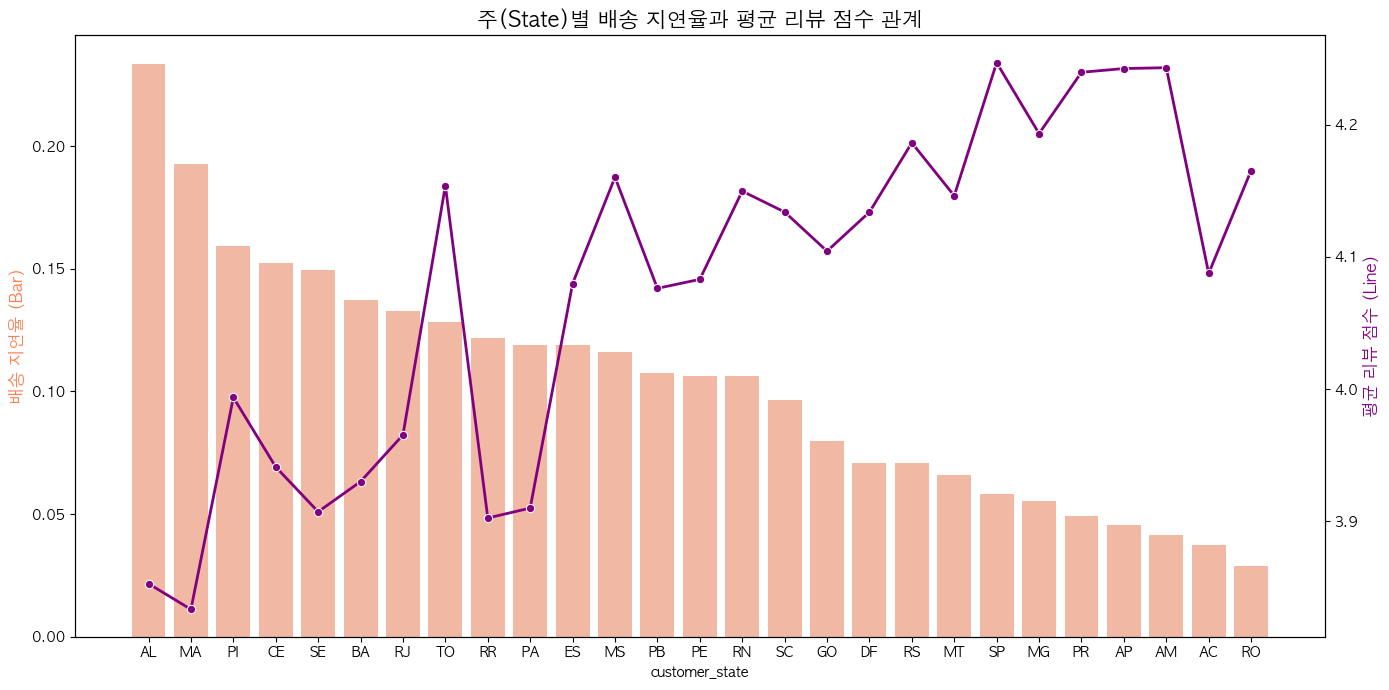

In [29]:
# 3. 지역별(State) 물류 효율 및 만족도 분석
state_analysis = df.groupby('customer_state').agg({
    'is_late': 'mean',
    'review_score': 'mean'
}).sort_values(by='is_late', ascending=False)

fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()

sns.barplot(x=state_analysis.index, y=state_analysis['is_late'], ax=ax1, alpha=0.6, color='coral')
sns.lineplot(x=state_analysis.index, y=state_analysis['review_score'], ax=ax2, color='purple', marker='o', linewidth=2)

ax1.set_ylabel('배송 지연율 (Bar)', color='coral', fontsize=12)
ax2.set_ylabel('평균 리뷰 점수 (Line)', color='purple', fontsize=12)
plt.title('주(State)별 배송 지연율과 평균 리뷰 점수 관계', fontsize=15)

plt.tight_layout()
plt.show()

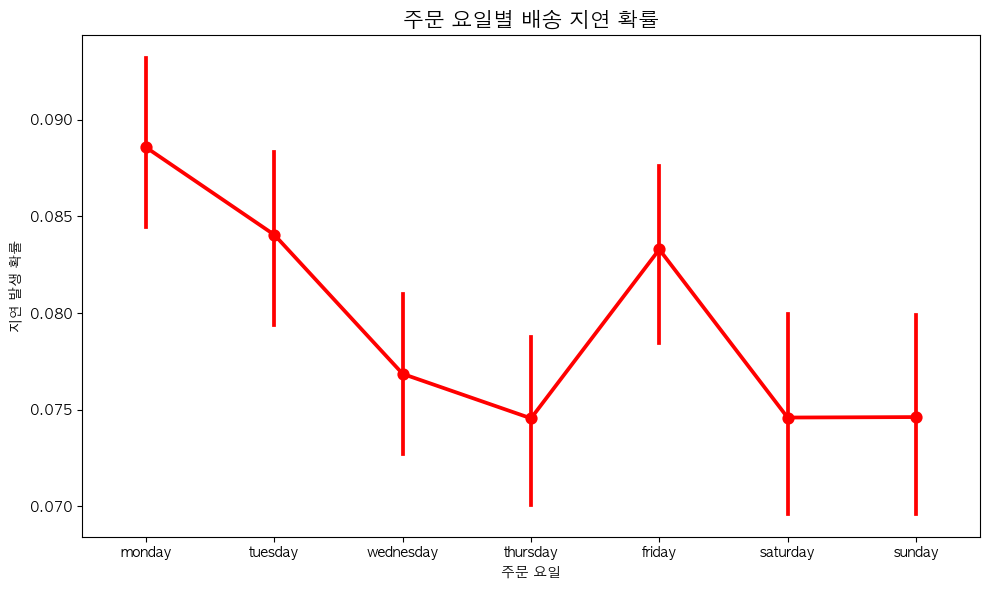

In [30]:
# 4. 요일별 배송 지연율
plt.figure(figsize=(10, 6))
day_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
sns.pointplot(x='order_purchase_dayofweek', y='is_late', data=df, order=day_order, color='red')
plt.title('주문 요일별 배송 지연 확률', fontsize=15)
plt.xlabel('주문 요일')
plt.ylabel('지연 발생 확률')

plt.tight_layout()
plt.show()

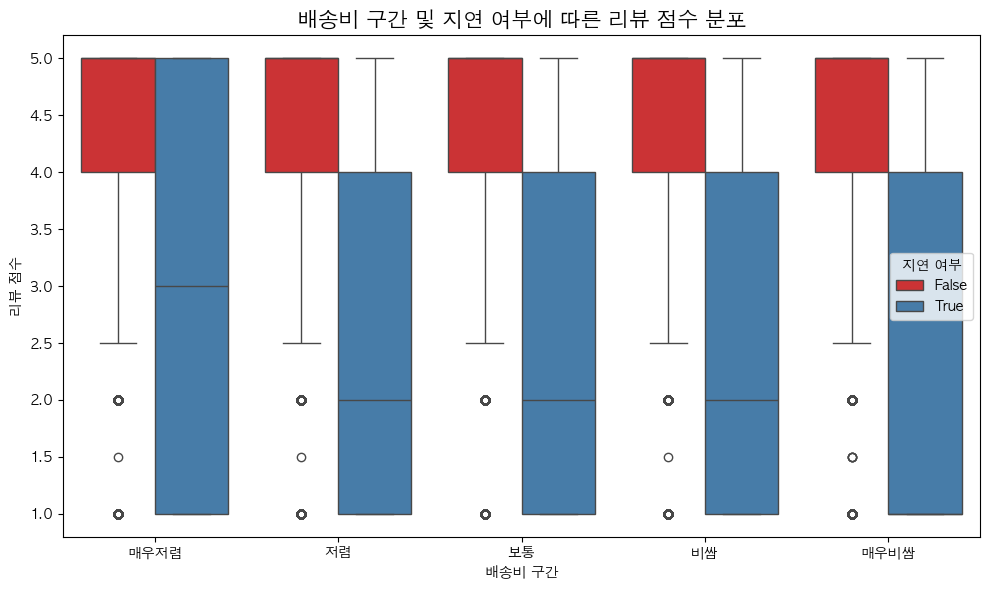

In [31]:
# 5. 배송비(Freight)와 만족도 상관관계 (배송비 구간별 평점)
df['freight_bin'] = pd.qcut(df['freight_value'], q=5, labels=['매우저렴', '저렴', '보통', '비쌈', '매우비쌈'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='freight_bin', y='review_score', hue='is_late', data=df, palette='Set1')
plt.title('배송비 구간 및 지연 여부에 따른 리뷰 점수 분포', fontsize=15)
plt.xlabel('배송비 구간')
plt.ylabel('리뷰 점수')
plt.legend(title='지연 여부')

plt.tight_layout()
plt.show()

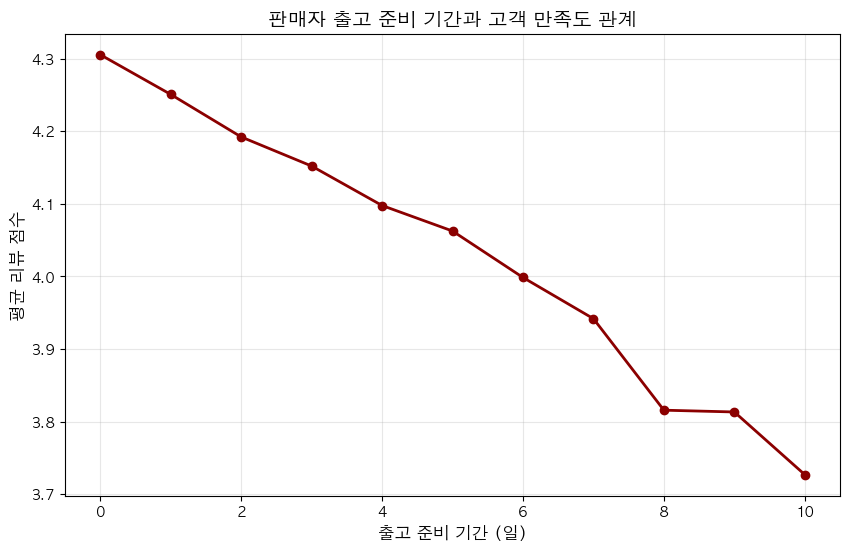

In [32]:
# 출고 기간(0~10일)별 평균 리뷰 점수 시각화
plt.figure(figsize=(10, 6))
dispatch_perf = df[df['dispatch_days'].between(0, 10)].groupby('dispatch_days')['review_score'].mean()

plt.plot(dispatch_perf.index, dispatch_perf.values, marker='o', color='darkred', linewidth=2)
plt.title('판매자 출고 준비 기간과 고객 만족도 관계', fontsize=14)
plt.xlabel('출고 준비 기간 (일)', fontsize=12)
plt.ylabel('평균 리뷰 점수', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

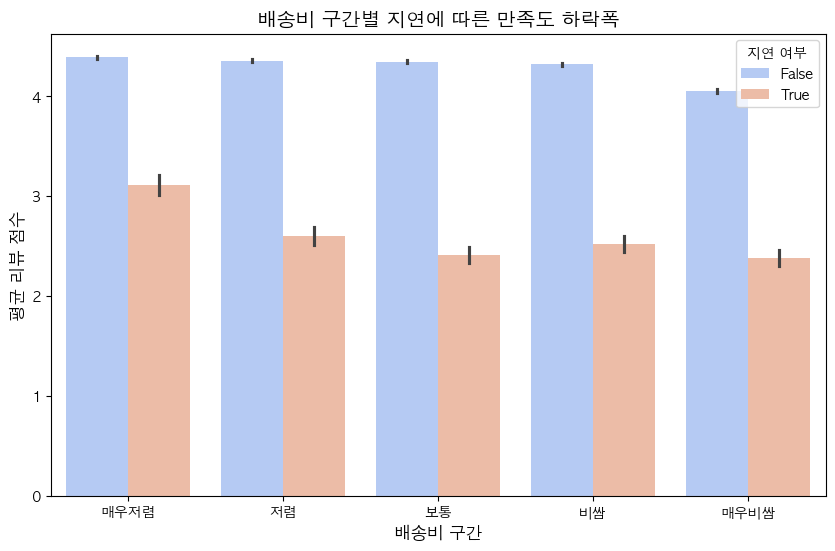

In [33]:
df['freight_bin'] = pd.qcut(df['freight_value'], q=5, labels=['매우저렴', '저렴', '보통', '비쌈', '매우비쌈'])

plt.figure(figsize=(10, 6))
sns.barplot(x='freight_bin', y='review_score', hue='is_late', data=df, palette='coolwarm')
plt.title('배송비 구간별 지연에 따른 만족도 하락폭', fontsize=14)
plt.xlabel('배송비 구간', fontsize=12)
plt.ylabel('평균 리뷰 점수', fontsize=12)
plt.legend(title='지연 여부', loc='upper right')
plt.show()

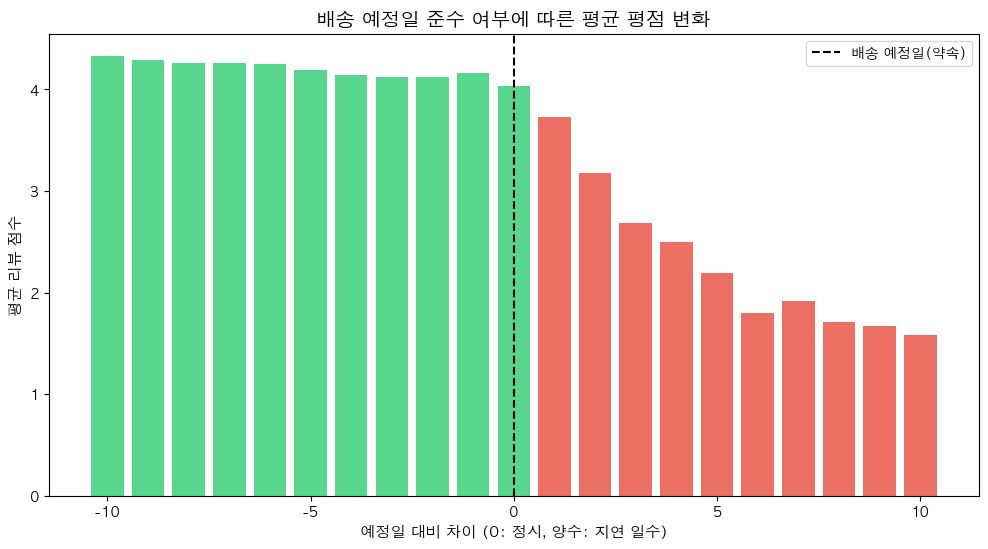

In [34]:
date_cols = [
    'order_purchase_timestamp', 
    'order_delivered_customer_date', 
    'order_estimated_delivery_date',
    'order_approved_at',
    'order_delivered_carrier_date'
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col])

# 예정일과의 차이 계산 (0: 정시, 양수: 지연, 음수: 조기 도착)
df['days_diff_from_est'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

plt.figure(figsize=(12, 6))
# -10일(조기)부터 +10일(지연) 구간 집중 분석
accuracy_perf = df[df['days_diff_from_est'].between(-10, 10)].groupby('days_diff_from_est')['review_score'].mean()
colors = ['#2ecc71' if x <= 0 else '#e74c3c' for x in accuracy_perf.index]

plt.bar(accuracy_perf.index, accuracy_perf.values, color=colors, alpha=0.8)
plt.axvline(0, color='black', linestyle='--', label='배송 예정일(약속)')
plt.title('배송 예정일 준수 여부에 따른 평균 평점 변화', fontsize=14)
plt.xlabel('예정일 대비 차이 (0: 정시, 양수: 지연 일수)', fontsize=11)
plt.ylabel('평균 리뷰 점수', fontsize=11)
plt.legend()
plt.show()

### 260304 여기까지